In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import copy
import numpy as np
import seaborn as sns
from tqdm import tqdm
from pathlib import Path
from torch.utils.data import DataLoader
from PIL import Image
from sklearn.metrics import confusion_matrix
from torchvision import models
from collections import Counter

In [2]:
transform_train = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(15),
    T.RandomAffine(degrees=0, scale=(0.9, 1.1), translate=(0.05, 0.05)),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.RandomApply([T.GaussianBlur(kernel_size=3)], p=0.1),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1)),
    T.RandomErasing(p=0.2, scale=(0.02, 0.08)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_val = T.Compose([
    T.Grayscale(num_output_channels=1),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Lambda(lambda x: x.repeat(3, 1, 1)),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [3]:
train_dataset = torchvision.datasets.ImageFolder(
    root="../../dataset/Face Dataset/Dataset Grayscale Face images/train",
    transform=transform_train
)

val_dataset = torchvision.datasets.ImageFolder(
    root="../../dataset/Face Dataset/Dataset Grayscale Face images/val",
    transform=transform_val
)

test_dataset = torchvision.datasets.ImageFolder(
    root="../../dataset/Face Dataset/Dataset Grayscale Face images/test",
    transform=transform_val
)

In [4]:
counts_train = Counter(train_dataset.targets)
counts_val = Counter(val_dataset.targets)
counts_test = Counter(test_dataset.targets)

print("Number of images in train")
for idx, count in counts_train.items():
    print(f"Class {idx}: {count}")

print("\nNumber of images in val")
for idx, count in counts_val.items():
    print(f"Class {idx}: {count}")

print("\nNumber of images in test")
for idx, count in counts_test.items():
    print(f"Class {idx}: {count}")

Number of images in train
Class 0: 11011
Class 1: 11904
Class 2: 11304
Class 3: 10642
Class 4: 11700
Class 5: 11697
Class 6: 10509
Class 7: 11276

Number of images in val
Class 0: 2359
Class 1: 2550
Class 2: 2422
Class 3: 2280
Class 4: 2507
Class 5: 2506
Class 6: 2252
Class 7: 2416

Number of images in test
Class 0: 2361
Class 1: 2552
Class 2: 2423
Class 3: 2281
Class 4: 2508
Class 5: 2507
Class 6: 2253
Class 7: 2417


In [5]:
batch_size = 32

trainloader = DataLoader(
                        train_dataset, 
                        batch_size=batch_size, 
                        shuffle=True, 
                        pin_memory=True, 
                        num_workers=0, 
                        persistent_workers=False, 
                        drop_last=True)

valloader = DataLoader(val_dataset, 
                       batch_size=batch_size * 2, 
                       shuffle=False, 
                       pin_memory=True, 
                       num_workers=0, 
                       persistent_workers=False)

testloader = DataLoader(test_dataset, 
                        batch_size=batch_size * 2, 
                        shuffle=False, 
                        pin_memory=True, 
                        num_workers=0, 
                        persistent_workers=False)

In [6]:
class FERACK_EfficientNetB2(nn.Module):
    def __init__(self, num_classes=8, freeze_backbone=True):
        super().__init__()

        self.backbone = models.efficientnet_b2(weights="IMAGENET1K_V1")

        if freeze_backbone:
            for param in self.backbone.features.parameters():
                param.requires_grad = False

        in_features = self.backbone.classifier[1].in_features

        self.backbone.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)
    
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FERACK_EfficientNetB2().to(device)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=5, eta_min=1e-6)

In [7]:
if device.type == "cuda":
    print("Training with CUDA")
else:
    print("Training with CPU")

Training with CUDA


In [8]:
model_dir = Path("../../model/Face Model")

checkpoint_path = model_dir / "FERACK_EfficientNetB2_checkpoint_B4.pth"
best_weights_path = model_dir / "FERACK_EfficientNetB2_best_weights_B4.pth"

n_epochs = 200
early_stopping = 10

if checkpoint_path.exists():
    print(f"\033[94m[INFO]\033[0m Resuming training from {checkpoint_path}")

    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)
    start_epoch = checkpoint['epoch'] + 1

    model.load_state_dict(checkpoint['model_state_dict'])

    if start_epoch > 5:
        print(f"\033[94m[INFO]\033[0m Continuing fine-tuning phase.")

        for param in model.backbone.features.parameters():
            param.requires_grad = True

        optimizer = optim.AdamW(
            [
                {"params": model.backbone.features.parameters(), "lr": 5e-6},
                {"params": model.backbone.classifier.parameters(), "lr": 5e-5}
            ],
            weight_decay=1e-4
        )

        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    else:
        print(f"\033[94m[INFO]\033[0m Continuing frozen phase.")

        optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5, eta_min=1e-6
        )
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    best_acc = checkpoint['best_acc']
    best_weights = checkpoint['best_weights']
    best_epoch = checkpoint['best_epoch']

    train_loss_hist = checkpoint['train_loss_hist']
    train_acc_hist = checkpoint['train_acc_hist']
    val_loss_hist = checkpoint['val_loss_hist']
    val_acc_hist = checkpoint['val_acc_hist']

    print(f"\033[94m[INFO]\033[0m Ready to continue from the {start_epoch} epoch.")

else:
    start_epoch = 0
    best_acc = -1
    best_epoch = -1

    train_acc_hist, train_loss_hist = [], []
    val_loss_hist, val_acc_hist = [], []

    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=5, eta_min=1e-6)

    print("\033[91m[ERROR]\033[0m No checkpoint found \n")
    print("\033[94m[INFO]\033[0m Starting training from scratch")

try:
    for epoch in range(start_epoch, n_epochs):

        if epoch == 5 and start_epoch <= 5:
            print(f"\033[94m[INFO]\033[0m Unfreezing backbone for fine-tuning.")

            for param in model.backbone.features.parameters():
                param.requires_grad = True

            optimizer = optim.AdamW(
                [
                    {"params": model.backbone.features.parameters(), "lr": 5e-6},
                    {"params": model.backbone.classifier.parameters(), "lr": 5e-5}
                ],
                weight_decay=1e-4
            )

            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10, eta_min=1e-6)

        epoch_loss = []
        epoch_acc = []

        model.train()

        with tqdm(trainloader, unit="batch") as bar:
            bar.set_description(f"Epoch {epoch}")

            for X_batch, y_batch in bar:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                acc = (torch.argmax(y_pred, 1) == y_batch).float().mean().item()

                epoch_loss.append(loss.item())
                epoch_acc.append(acc)

                bar.set_postfix(loss=loss.item(), acc=acc)

        train_acc_hist.append(np.mean(epoch_acc))
        train_loss_hist.append(np.mean(epoch_loss))

        model.eval()

        val_loss = []
        val_acc = []

        with torch.no_grad():
            for X_batch, y_batch in valloader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(X_batch)
                loss = loss_fn(y_pred, y_batch)

                acc = (torch.argmax(y_pred, 1) == y_batch).float().mean().item()

                val_loss.append(loss.item())
                val_acc.append(acc)

        acc = np.mean(val_acc)
        ce = np.mean(val_loss)

        val_acc_hist.append(acc)
        val_loss_hist.append(ce)

        scheduler.step()

        if acc > best_acc:
            best_acc = acc
            best_epoch = epoch
            best_weights = copy.deepcopy(model.state_dict())

            torch.save(best_weights, best_weights_path)

            print(f"\033[94m[INFO]\033[0m Best Accuracy with value {best_acc * 100:.4f} in the epoch {best_epoch}")

        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_weights': best_weights,
            'best_acc': best_acc,
            'best_epoch': best_epoch,
            'train_loss_hist': train_loss_hist,
            'train_acc_hist': train_acc_hist,
            'val_loss_hist': val_loss_hist,
            'val_acc_hist': val_acc_hist
        }

        torch.save(checkpoint, checkpoint_path)

        if epoch > 5 and (epoch - best_epoch > early_stopping):
            break

        print(f"Epoch {epoch} Accuracy {acc*100:.2f}, validation: Cross-entropy = {ce:.2f}")

    print(f"\033[94m[INFO]\033[0m Best model saved with accuracy {best_acc*100:.4f}%")

except KeyboardInterrupt:
    print("\033[93m[WARNING]\033[0m Training stopped manually")

[INFO] Resuming training from ../../model/Face Model/FERACK_EfficientNetB2_checkpoint_B4.pth
[INFO] Continuing fine-tuning phase.
[INFO] Ready to continue from the 117 epoch.


Epoch 117: 100%|██████████| 2813/2813 [10:37<00:00,  4.42batch/s, acc=0.781, loss=0.885]


Epoch 117 Accuracy 74.39, validation: Cross-entropy = 1.04


Epoch 118: 100%|██████████| 2813/2813 [10:17<00:00,  4.55batch/s, acc=0.812, loss=0.906]


Epoch 118 Accuracy 74.40, validation: Cross-entropy = 1.04


...

[INFO] Best Accuracy with value 75.8515 in the epoch 142
Epoch 142 Accuracy 75.85, validation: Cross-entropy = 1.02


Epoch 143: 100%|██████████| 2813/2813 [10:15<00:00,  4.57batch/s, acc=0.75, loss=0.966] 


Epoch 143 Accuracy 75.74, validation: Cross-entropy = 1.02


Epoch 144:  19%|█▉        | 543/2813 [02:00<08:25,  4.49batch/s, acc=0.844, loss=0.858]

[WARNING] Training stopped manually


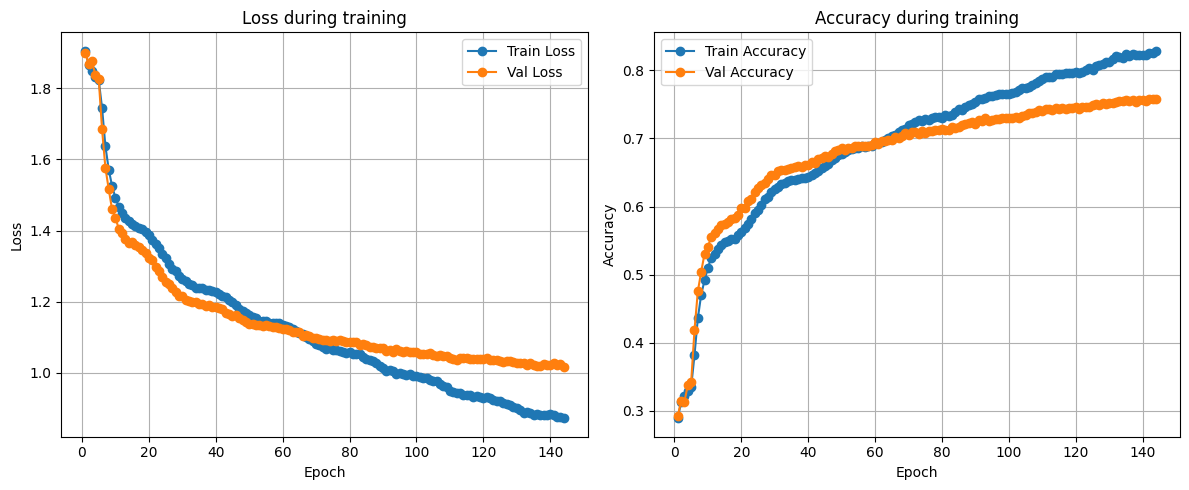

In [9]:
model_dir = Path("../../model/Face Model")

checkpoint_path = model_dir / "FERACK_EfficientNetB2_checkpoint_B4.pth"

checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

epochs = range(1, len(checkpoint['train_acc_hist']) + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, checkpoint['train_loss_hist'], label="Train Loss", marker='o')
plt.plot(epochs, checkpoint['val_loss_hist'], label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during training")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs, checkpoint['train_acc_hist'], label="Train Accuracy", marker='o')
plt.plot(epochs, checkpoint['val_acc_hist'], label="Val Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy during training")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

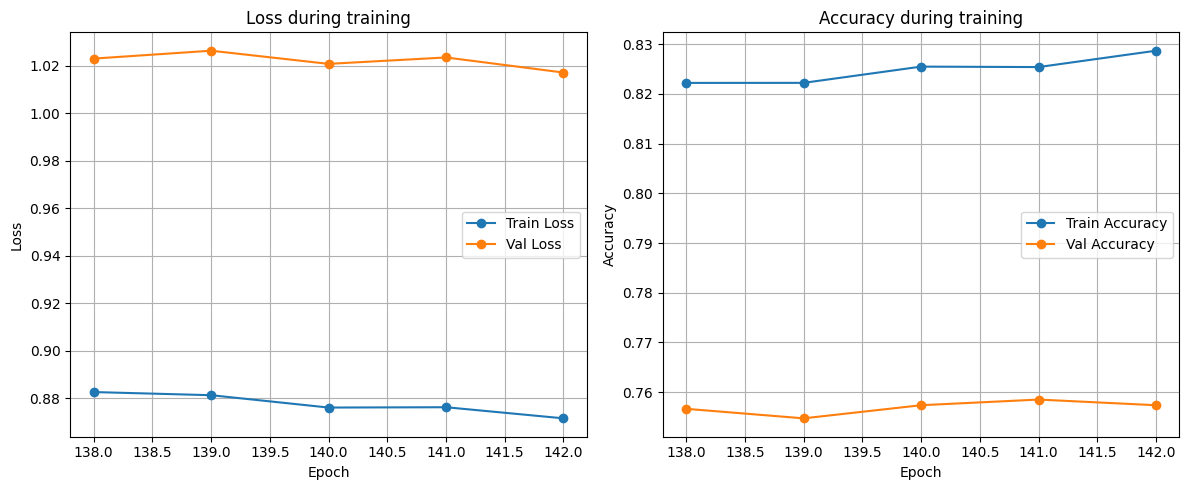

In [11]:
model_dir = Path("../../model/Face Model")

checkpoint_path = model_dir / "FERACK_EfficientNetB2_checkpoint_B4.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

distance = 5

epochs = range(checkpoint['epoch'] - distance, checkpoint['epoch'])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(epochs, checkpoint['train_loss_hist'][-distance:], label="Train Loss", marker='o')
plt.plot(epochs, checkpoint['val_loss_hist'][-distance:], label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during training")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs, checkpoint['train_acc_hist'][-distance:], label="Train Accuracy", marker='o')
plt.plot(epochs, checkpoint['val_acc_hist'][-distance:], label="Val Accuracy", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy during training")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [12]:
model = FERACK_EfficientNetB2()
model.load_state_dict(torch.load("../../model/Face Model/FERACK_EfficientNetB2_best_weights_B4.pth", map_location=device))
model.to(device)

FERACK_EfficientNetB2(
  (backbone): EfficientNet(
    (features): Sequential(
      (0): Conv2dNormActivation(
        (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): SiLU(inplace=True)
      )
      (1): Sequential(
        (0): MBConv(
          (block): Sequential(
            (0): Conv2dNormActivation(
              (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
              (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
              (2): SiLU(inplace=True)
            )
            (1): SqueezeExcitation(
              (avgpool): AdaptiveAvgPool2d(output_size=1)
              (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
              (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
              (activation): SiLU(inplace=True)
           

In [13]:
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch , y_batch in testloader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

In [14]:
cm = confusion_matrix(all_labels, all_preds)
cm

array([[1470,  113,  159,  127,   34,  138,  233,   87],
       [  35, 2298,   42,   12,   19,   61,   32,   53],
       [ 122,  108, 1960,   53,   19,   21,   79,   61],
       [ 133,   38,   61, 1311,   37,   88,  284,  329],
       [  21,    6,    1,   10, 2273,  130,   20,   47],
       [  41,   25,    7,   34,  130, 2083,  145,   42],
       [ 185,   97,   68,  140,   39,  214, 1425,   85],
       [  53,   77,   44,  176,   46,   65,   79, 1877]])

In [15]:
train_dataset.class_to_idx

{'anger': 0,
 'contempt': 1,
 'disgust': 2,
 'fear': 3,
 'happy': 4,
 'neutral': 5,
 'sad': 6,
 'surprise': 7}

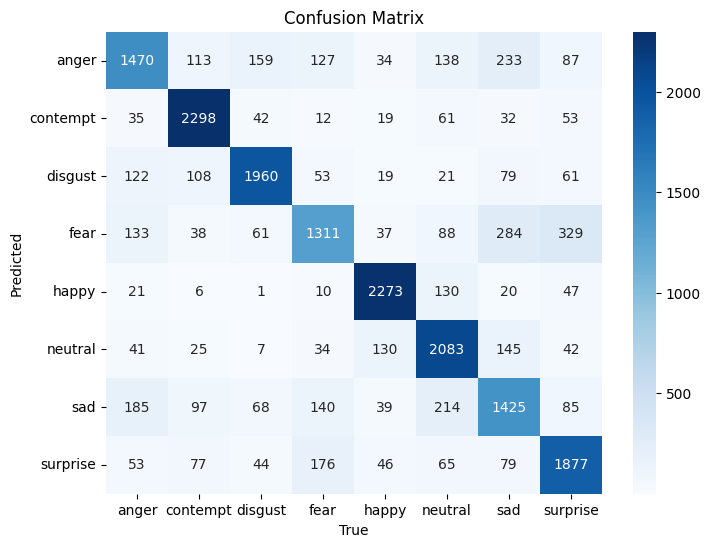

In [16]:
emotions = ['anger','contempt','disgust','fear','happy','neutral','sad','surprise']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=emotions, yticklabels=emotions, cmap='Blues')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Confusion Matrix')
plt.show()